# Question Answering Success Analysis

In this notebook the the performance of the boardgame rulebook question answering system will be analyzed. It loads question-answer results, computes success metrics, and visualizes the results with graphs.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

%matplotlib inline

## Load Question Answering Results Data

Load the results data (CSV or JSON) containing ground truth answers and predicted answers. Update the file path as needed.

In [32]:
# Example: Load results from a CSV or JSON file
# Update the file path as needed
results_path = '../data/processed/qa_results.csv'  # or .json

# Try loading CSV, fallback to JSON
try:
    df = pd.read_csv(results_path)
except Exception:
    df = pd.read_json(results_path)

df.head()

,question,ground_truth,predicted,overall_score,relevance_score,completeness_score,accuracy_score,conciseness_score,question_type,page,section,chunk_index,best_chunk_rank
0,When do I increase my radiation?,Each time a Stalker slides their Turn token (a...,]pending time in such places will cause you to...,0.826040,0.869346,1.00,0.487076,1.0,procedural,41,ENTITIES COMPARISON TABLE,NaN,5.0
1,How do I win the mission?,Each Mission has a main Objective card which s...,you're ready to startǴ\n\nOpen the ampaign bin...,0.495791,0.135208,1.00,0.193872,1.0,procedural,7,STARTING THE CAMPAIGN,NaN,NaN
2,How many players can play this game?,This game can be played by 1-4 players.,Unknown tokens\n:\n Depending on the number\no...,0.369820,0.047805,0.75,0.112354,1.0,procedural,10,MISSION SETUP IN MISSION GUIDE,NaN,16.0
3,How does movement work?,"On your turn, when you use the Move action, yo...",There are two types of Movement that Enemies p...,0.699201,0.650273,1.00,0.286420,1.0,procedural,32,ENEMY MOVEMENT RULES,NaN,NaN
4,How do I perform an attack action?,Choose an Attack Action and a valid Target. - ...,To perform an Attack follow these steps:\n\n1....,0.867547,0.956819,1.00,0.530642,1.0,procedural,44,STALKER ATTACK SEQUENCE,NaN,NaN


## Preprocess and Explore Data

Clean and preprocess the data, handle missing values, and display basic statistics about the dataset.

In [33]:
# Drop rows with missing values in essential columns only
clean_df = df.dropna(subset=['question', 'ground_truth', 'predicted'])

# Show basic statistics
print('Number of questions:', len(clean_df))
print('Columns:', clean_df.columns.tolist())
clean_df.describe(include='all')

Number of questions: 39
Columns: ['question', 'ground_truth', 'predicted', 'overall_score', 'relevance_score', 'completeness_score', 'accuracy_score', 'conciseness_score', 'question_type', 'page', 'section', 'chunk_index', 'best_chunk_rank']


,question,ground_truth,predicted,overall_score,relevance_score,completeness_score,accuracy_score,conciseness_score,question_type,page,section,chunk_index,best_chunk_rank
count,39,39,39,39.000000,39.000000,39.000000,39.000000,39.000000,39,39.000000,39,0.0,15.000000
unique,39,38,39,NaN,NaN,NaN,NaN,NaN,5,NaN,19,NaN,NaN
top,When do I increase my radiation?,"When any Stalker dies, you fail your current M...",]pending time in such places will cause you to...,NaN,NaN,NaN,NaN,NaN,procedural,NaN,FIRST AID KIT\nMEDICINE,NaN,NaN
freq,1,2,1,NaN,NaN,NaN,NaN,NaN,22,NaN,5,NaN,NaN
mean,NaN,NaN,NaN,0.657651,0.576616,0.911172,0.350074,0.949654,NaN,19.538462,NaN,NaN,7.266667
std,NaN,NaN,NaN,0.177749,0.345183,0.135604,0.235317,0.093947,NaN,13.539117,NaN,NaN,7.401416
min,NaN,NaN,NaN,0.319763,0.021786,0.542857,0.022619,0.595000,NaN,4.000000,NaN,NaN,1.000000
25%,NaN,NaN,NaN,0.523037,0.217725,0.825000,0.156288,0.942000,NaN,7.500000,NaN,NaN,1.500000
50%,NaN,NaN,NaN,0.699201,0.764109,1.000000,0.351912,1.000000,NaN,17.000000,NaN,NaN,4.000000
75%,NaN,NaN,NaN,0.812570,0.856180,1.000000,0.520831,1.000000,NaN,32.500000,NaN,NaN,12.000000


## Calculate Success Metrics Using Similarity

Compute and visualize fuzzy string similarity (token set ratio) for the question answering results. This provides a more realistic measure of model performance for free-form answers.

## Multi-Dimensional Scoring Analysis (if available)

If the results include multi-dimensional scores, display breakdown by dimension.

Multi-Dimensional Scoring Results
Overall Score:      65.77%
  Relevance (35%):  57.66%
  Completeness (30%): 91.12%
  Accuracy (25%):   35.01%
  Conciseness (10%): 94.97%

Passing (≥80%):     11/39


C:\Users\I544554\AppData\Local\Temp\ipykernel_40268\1012239527.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dimension_data.values(), labels=dimension_data.keys())


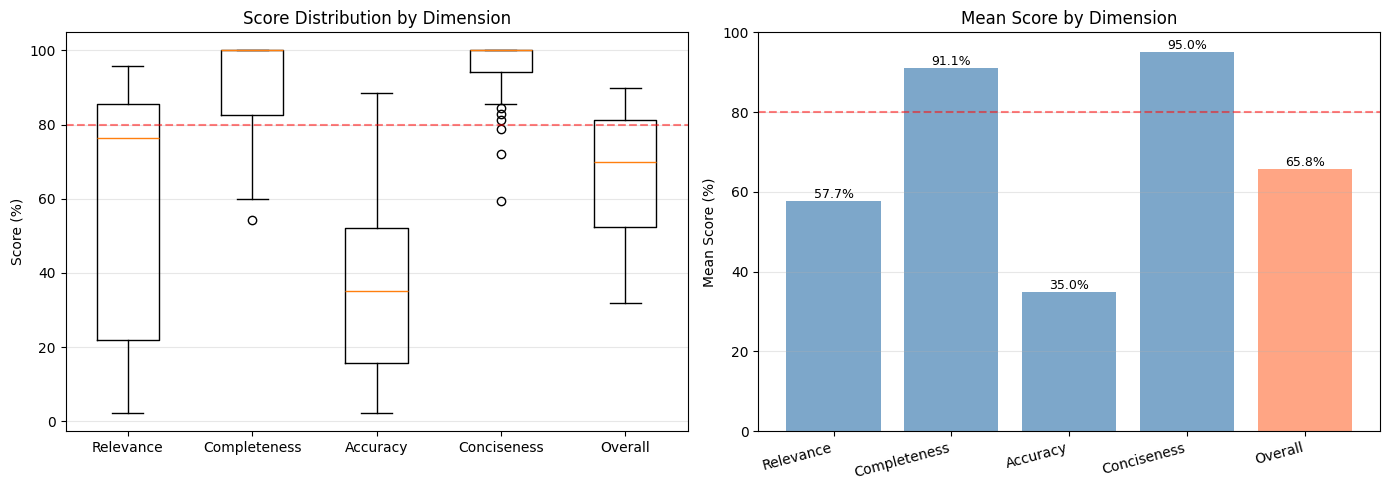

In [34]:
# Check if multi-dimensional scores are available
multidim_cols = ['overall_score', 'relevance_score', 'completeness_score', 'accuracy_score', 'conciseness_score']

if all(col in clean_df.columns for col in multidim_cols):
    print("Multi-Dimensional Scoring Results")
    print("="*70)
    print(f"Overall Score:      {clean_df['overall_score'].mean():.2%}")
    print(f"  Relevance (35%):  {clean_df['relevance_score'].mean():.2%}")
    print(f"  Completeness (30%): {clean_df['completeness_score'].mean():.2%}")
    print(f"  Accuracy (25%):   {clean_df['accuracy_score'].mean():.2%}")
    print(f"  Conciseness (10%): {clean_df['conciseness_score'].mean():.2%}")
    print(f"\nPassing (≥80%):     {(clean_df['overall_score'] >= 0.8).sum()}/{len(clean_df)}")
    print("="*70)
    
    # Visualize dimension breakdown
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot of all dimensions
    ax = axes[0]
    dimension_data = {
        'Relevance': clean_df['relevance_score'] * 100,
        'Completeness': clean_df['completeness_score'] * 100,
        'Accuracy': clean_df['accuracy_score'] * 100,
        'Conciseness': clean_df['conciseness_score'] * 100,
        'Overall': clean_df['overall_score'] * 100
    }
    ax.boxplot(dimension_data.values(), labels=dimension_data.keys())
    ax.set_ylabel('Score (%)')
    ax.set_title('Score Distribution by Dimension')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
    
    # Bar plot of mean scores
    ax = axes[1]
    means = [v.mean() for v in dimension_data.values()]
    colors = ['steelblue', 'steelblue', 'steelblue', 'steelblue', 'coral']
    bars = ax.bar(dimension_data.keys(), means, color=colors, alpha=0.7)
    ax.set_ylabel('Mean Score (%)')
    ax.set_title('Mean Score by Dimension')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=80, color='red', linestyle='--', alpha=0.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)
    
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Multi-dimensional scores not available in this dataset")
    print("Available columns:", clean_df.columns.tolist())


Using multi-dimensional overall_score from CSV (0-100 scale)
Mean similarity: 65.77
Questions passing threshold: 11/39


C:\Users\I544554\AppData\Local\Temp\ipykernel_40268\2604032173.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['similarity'] = clean_df['overall_score'] * 100
C:\Users\I544554\AppData\Local\Temp\ipykernel_40268\2604032173.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['correct'] = clean_df['similarity'] >= threshold


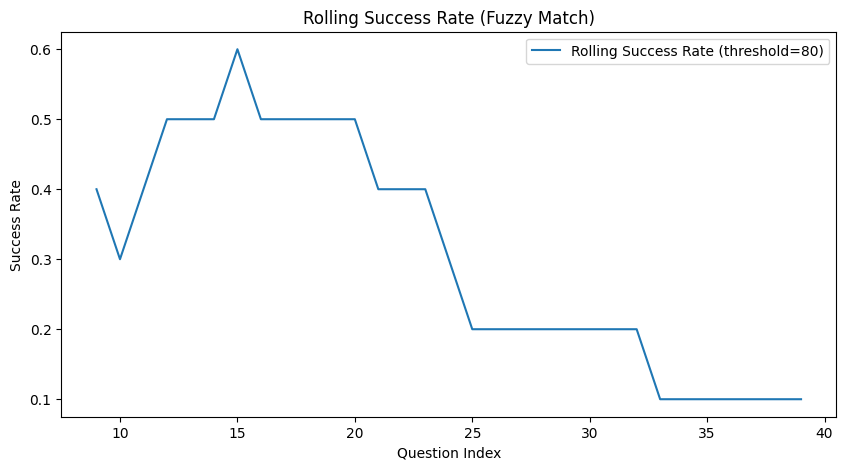

In [35]:
# Define threshold for fuzzy match success
threshold = 80

# Handle different score column formats from QA batch runs
if 'overall_score' in clean_df.columns:
    # Multi-dimensional scoring format (0-1 scale) - USE THIS for new runs
    clean_df['similarity'] = clean_df['overall_score'] * 100
    print('Using multi-dimensional overall_score from CSV (0-100 scale)')
elif 'score' in clean_df.columns and 'similarity' not in clean_df.columns:
    # Old single-score format (0-1 scale)
    clean_df['similarity'] = clean_df['score'] * 100
    print('Using pre-computed similarity scores from CSV (old format)')
elif 'similarity' not in clean_df.columns:
    # Fallback: compute text similarity if not present
    try:
        from rapidfuzz import fuzz
    except ImportError:
        import sys, subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz'])
        from rapidfuzz import fuzz
    similarities = [fuzz.token_set_ratio(str(gt), str(pred)) for gt, pred in zip(clean_df['ground_truth'], clean_df['predicted'])]
    clean_df['similarity'] = similarities
    print('Computed text similarity scores using rapidfuzz (fallback)')

clean_df['correct'] = clean_df['similarity'] >= threshold

print(f'Mean similarity: {clean_df["similarity"].mean():.2f}')
print(f'Questions passing threshold: {clean_df["correct"].sum()}/{len(clean_df)}')

# Rolling success rate
window = 10
rolling_success = clean_df['correct'].rolling(window).mean()
plt.figure(figsize=(10,5))
plt.plot(rolling_success, label=f'Rolling Success Rate (threshold={threshold})')
plt.xlabel('Question Index')
plt.ylabel('Success Rate')
plt.title('Rolling Success Rate (Fuzzy Match)')
plt.legend()
plt.show()


## Fuzzy String Similarity Analysis

Since exact string match metrics are too strict for free-form answers, we use fuzzy string similarity to better gauge answer quality.

Mean similarity: 65.77


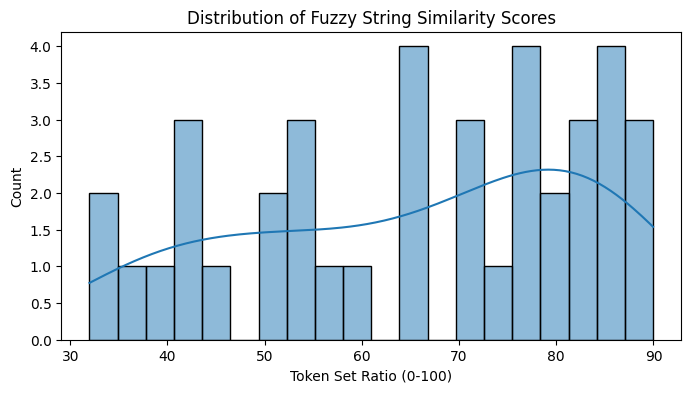

In [36]:
# Use the similarity scores already computed in the previous cell
similarities = clean_df['similarity'].tolist()

print(f'Mean similarity: {np.mean(similarities):.2f}')
plt.figure(figsize=(8,4))
sns.histplot(similarities, bins=20, kde=True)
plt.title('Distribution of Fuzzy String Similarity Scores')
plt.xlabel('Token Set Ratio (0-100)')
plt.ylabel('Count')
plt.show()

## Fuzzy Match Confusion Matrix

We treat predictions as correct if their similarity is above the threshold, and plot a confusion matrix.

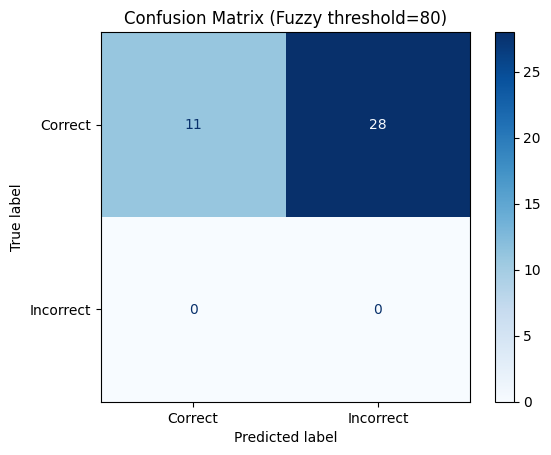

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# True: all answers are expected to be correct (since each row is a QA pair)
y_true_bin = np.ones(len(clean_df), dtype=int)
y_pred_bin = clean_df['correct'].astype(int)

cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[1,0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Correct', 'Incorrect'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (Fuzzy threshold={threshold})')
plt.show()

## Visualize Success Rate Over Time (Fuzzy Match)

We define a prediction as 'correct' if its similarity to the ground truth is above a threshold (e.g., 80).

Found 136 valid archive files


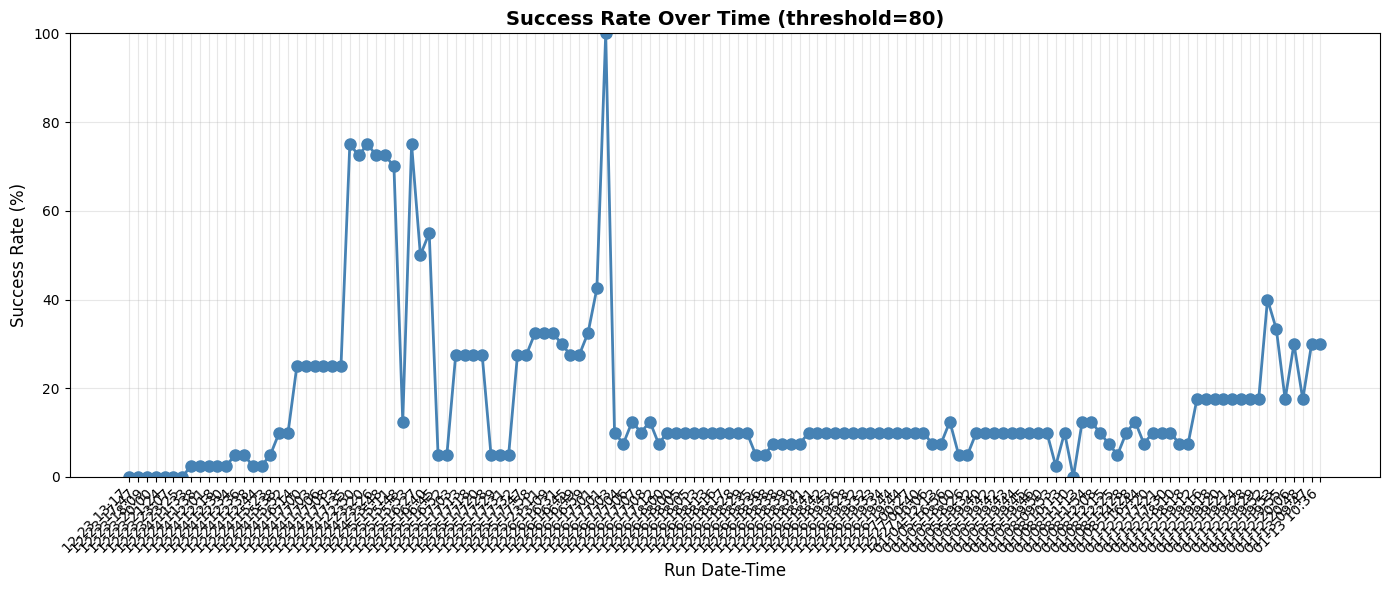


Success rate range: 0.0% to 100.0%
Latest success rate: 30.0%


In [38]:
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Find all archived qa_results files
archive_files = sorted(glob.glob('../data/processed/archive/qa_results_*.csv'))

# Extract datetime from filename
pattern = re.compile(r'qa_results_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})_\d+s')

def extract_dt(fname):
    match = pattern.search(fname)
    if match:
        return match.group(1)
    return None

# Filter and sort by datetime
valid_files = []
for f in archive_files:
    dt_str = extract_dt(f)
    if dt_str:
        valid_files.append((f, dt_str))

valid_files = sorted(valid_files, key=lambda x: x[1])

success_rates = []
datetimes = []
file_labels = []
threshold = 80

print(f"Found {len(valid_files)} valid archive files")

for f, dt in valid_files:
    try:
        df = pd.read_csv(f)
        
        # Handle different score column formats
        if 'overall_score' in df.columns:
            # Multi-dimensional scoring format (0-1 scale)
            similarity_scores = df['overall_score'] * 100
        elif 'score' in df.columns:
            # Old format with single score (0-1 scale)
            similarity_scores = df['score'] * 100
        elif 'similarity' in df.columns:
            # Already computed similarity
            similarity_scores = df['similarity']
        else:
            # Compute similarity if not present
            try:
                from rapidfuzz import fuzz
                similarity_scores = [fuzz.token_set_ratio(str(gt), str(pred)) 
                                   for gt, pred in zip(df['ground_truth'], df['predicted'])]
            except:
                print(f"Skipping {f}: cannot compute similarity")
                continue
        
        correct = (pd.Series(similarity_scores) >= threshold).mean()
        success_rates.append(correct * 100)  # Convert to percentage
        datetimes.append(dt)
        
        # Create short label from datetime
        dt_obj = datetime.strptime(dt, '%Y-%m-%d_%H-%M-%S')
        file_labels.append(dt_obj.strftime('%m-%d %H:%M'))
    except Exception as e:
        print(f"Error processing {f}: {e}")

if not success_rates:
    print("No valid data found to plot")
else:
    plt.figure(figsize=(14, 6))
    plt.plot(range(len(success_rates)), success_rates, marker='o', linewidth=2, markersize=8, color='steelblue')
    
    plt.xticks(range(len(success_rates)), file_labels, rotation=45, ha='right')
    plt.xlabel('Run Date-Time', fontsize=12)
    plt.ylabel('Success Rate (%)', fontsize=12)
    plt.title(f'Success Rate Over Time (threshold={threshold})', fontsize=14, fontweight='bold')
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nSuccess rate range: {min(success_rates):.1f}% to {max(success_rates):.1f}%")
    print(f"Latest success rate: {success_rates[-1]:.1f}%")


## Compare Different Hybrid Search Weights

Compare the performance of different vector vs keyword weight configurations to find the optimal balance.


HYBRID SEARCH WEIGHT COMPARISON
                Weight Config  Mean Similarity  Success Rate  Success Count  Total
w20 (20% vector, 80% keyword)        42.193873          0.10              4     40
w30 (30% vector, 70% keyword)        42.193873          0.10              4     40
w40 (40% vector, 60% keyword)        42.193873          0.10              4     40
w50 (50% vector, 50% keyword)        42.120203          0.10              4     40
w60 (60% vector, 40% keyword)        42.148607          0.10              4     40
w70 (70% vector, 30% keyword)        41.594793          0.10              4     40
w80 (80% vector, 20% keyword)        41.594793          0.10              4     40
w85 (85% vector, 15% keyword)        37.499652          0.05              2     40
w90 (90% vector, 10% keyword)        41.594793          0.10              4     40



HYBRID SEARCH WEIGHT COMPARISON
                Weight Config  Mean Similarity  Success Rate  Success Count  Total
w20 (20% vector, 80% keyword)        42.193873          0.10              4     40
w30 (30% vector, 70% keyword)        42.193873          0.10              4     40
w40 (40% vector, 60% keyword)        42.193873          0.10              4     40
w50 (50% vector, 50% keyword)        42.120203          0.10              4     40
w60 (60% vector, 40% keyword)        42.148607          0.10              4     40
w70 (70% vector, 30% keyword)        41.594793          0.10              4     40
w80 (80% vector, 20% keyword)        41.594793          0.10              4     40
w85 (85% vector, 15% keyword)        37.499652          0.05              2     40
w90 (90% vector, 10% keyword)        41.594793          0.10              4     40


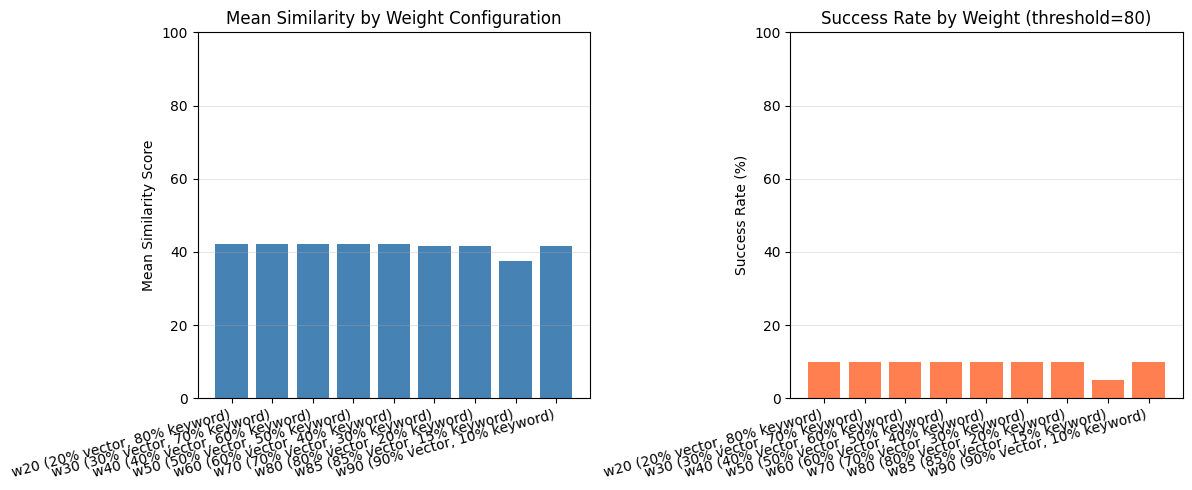

In [11]:
import glob
import pandas as pd
from rapidfuzz import fuzz
import numpy as np

# Find weight test files
weight_files = {
    'w20 (20% vector, 80% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-40-53_19s-20.csv',
    'w30 (30% vector, 70% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-42-13_19s-30.csv',
    'w40 (40% vector, 60% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-42-51_18s-40.csv',
    'w50 (50% vector, 50% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-43-26_18s-50.csv',
    'w60 (60% vector, 40% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-50-07_19s-60.csv',
    'w70 (70% vector, 30% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-44-54_18s-70.csv',
    'w80 (80% vector, 20% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-45-28_18s-80.csv',
    'w85 (85% vector, 15% keyword)': '../data/processed/archive/qa_results_2026-01-05_18-26-54_21s.csv',
    'w90 (90% vector, 10% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-46-03_19s-90.csv',
}

threshold = 80
comparison_results = []

for weight_label, filepath in weight_files.items():
    try:
        df = pd.read_csv(filepath)
        
        # Calculate similarities if not present
        if 'similarity' not in df.columns:
            similarities = [fuzz.token_set_ratio(str(gt), str(pred)) 
                          for gt, pred in zip(df['ground_truth'], df['predicted'])]
            df['similarity'] = similarities
        
        # Calculate metrics
        mean_sim = df['similarity'].mean()
        success_rate = (df['similarity'] >= threshold).mean()
        
        comparison_results.append({
            'Weight Config': weight_label,
            'Mean Similarity': mean_sim,
            'Success Rate': success_rate,
            'Success Count': (df['similarity'] >= threshold).sum(),
            'Total': len(df)
        })
    except FileNotFoundError:
        print(f"File not found: {filepath}")

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_results)
print("\n" + "="*70)
print("HYBRID SEARCH WEIGHT COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(len(comparison_df)), comparison_df['Mean Similarity'], color='steelblue')
plt.xticks(range(len(comparison_df)), comparison_df['Weight Config'], rotation=15, ha='right')
plt.ylabel('Mean Similarity Score')
plt.title('Mean Similarity by Weight Configuration')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(len(comparison_df)), comparison_df['Success Rate'] * 100, color='coral')
plt.xticks(range(len(comparison_df)), comparison_df['Weight Config'], rotation=15, ha='right')
plt.ylabel('Success Rate (%)')
plt.title(f'Success Rate by Weight (threshold={threshold})')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()